##### Laden der Module

In [1]:
import numpy as np
import scipy
import cv2
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

##### Hilfsfunktionen laden

In [2]:
def displayImageAndAllHist(image, title = 'Bild'):
    """Display a grayscale image with its histogram and cumulative histogram.

    Parameters:
    - image (numpy.ndarray): uint8 image, grayscale
    - title (str): Plot title.
    """

    histo, edges = np.histogram(image, bins=256, range=(0, 256))
    cumHisto = np.cumsum(histo)
    
    # Matplotlib Plot mit Bild und Histogramm
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # Bild anzeigen
    axs[0].imshow(image, cmap='gray', vmin=0, vmax=255)
    axs[0].set_title(title)
    axs[0].axis('off')

    # Histogramm
    axs[1].bar(range(len(histo)), histo)
    axs[1].set_title('Histogramm')
    axs[1].set_xlabel('Grauwert')
    axs[1].set_ylabel('Anzahl')

    # Kumuliertes Histogramm
    axs[2].plot(range(len(cumHisto)), cumHisto, color='red')
    axs[2].set_ylim(0, image.size)
    axs[2].set_title('Kumuliertes Histogramm')
    axs[2].set_xlabel('Grauwert')
    axs[2].set_ylabel('Kumuliert')

    plt.tight_layout()
    plt.show()

##### Einlesen des Bildes

Einlesen des Bildes und Anzeige der Bildinformationen

In [3]:
# Bilddateien einladen
image = cv2.imread(r'images/airplane.tif', cv2.IMREAD_GRAYSCALE)

Datentyp des Bildes: uint8
fortmat des Bildes: (480, 640)


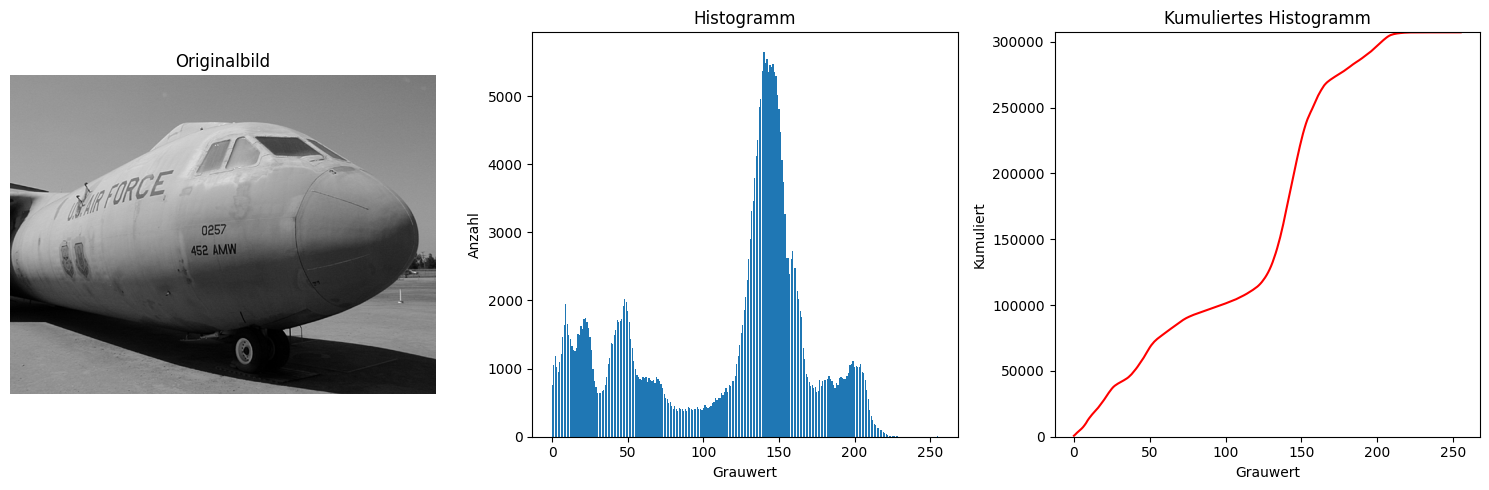

In [4]:
dataType = image.dtype
imageShape = image.shape
print(f'Datentyp des Bildes: {dataType}')
print(f'fortmat des Bildes: {imageShape}')


displayImageAndAllHist(image, title = 'Originalbild')

## Invertieren des Bildes

#### Aufgabe:

Invertieren Sie das Bild und zeigen Sie das invertierte Bild zusammen mit den Histogrammen an. Nutzen Sie zur Anzeige die Funktion displayImageAndAllHist().

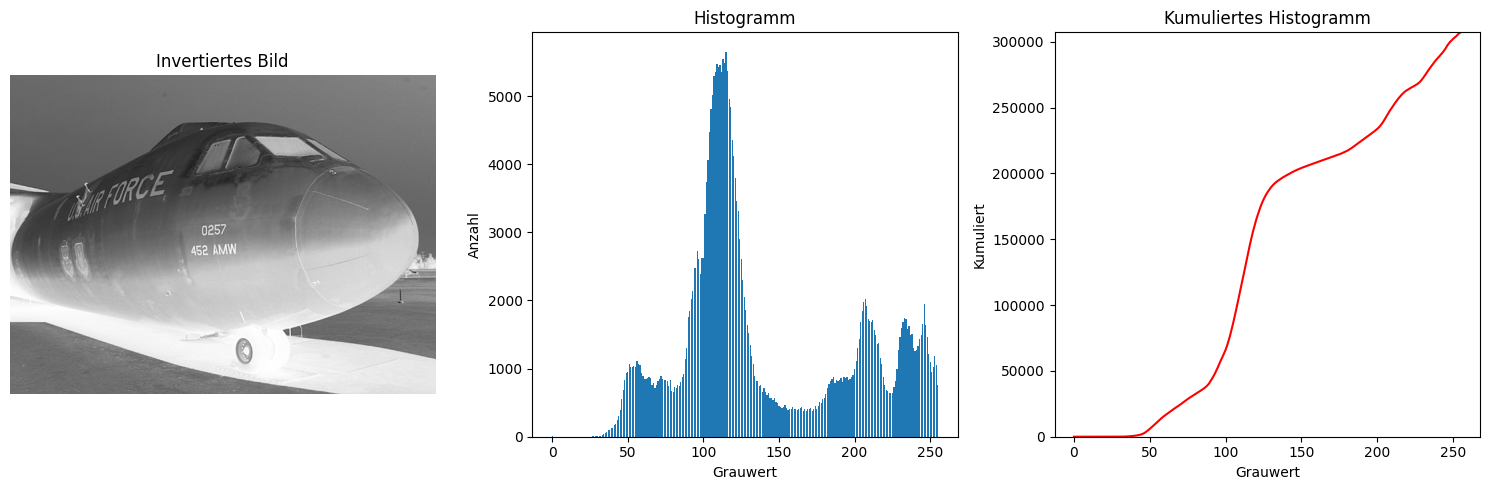

In [5]:
##########
### ENTER YOUR CODE HERE
##########

image_inverted = 255-image

displayImageAndAllHist(image_inverted, title = 'Invertiertes Bild')

### Schwellwertoperation

#### Aufgabe:
Implemenieren Sie eine Funktion die das Bild durch eine Schwellwertoperation in ein Binärbild umwandelt.  Zeigen Sie das Ergebnisbild zusammen mit den Histogrammen an. Nutzen Sie zur Anzeige die Funktion displayImageAndAllHist().
Wandeln Sie das Bild durch eine Schwellwertoperation in ein Binärbild um. Zeigen Sie das Ergebnisbild zusammen mit den Histogrammen an. Nutzen Sie zur Anzeige die Funktion displayImageAndAllHist().

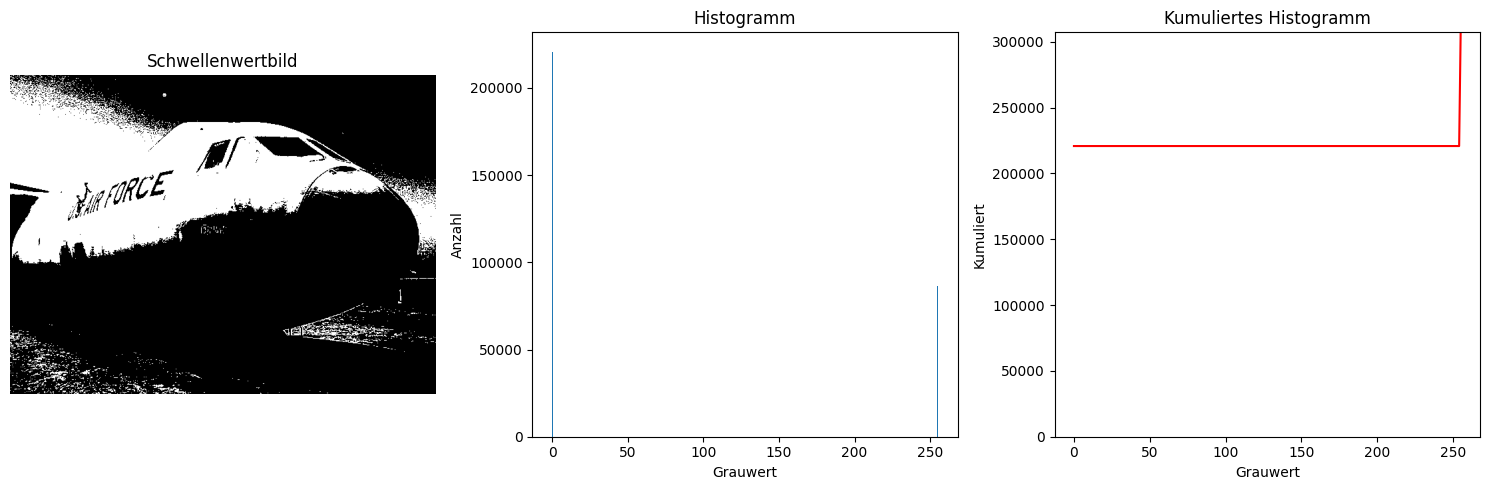

In [6]:
def thresholdImage(image, threshold):
    """Apply a threshold operation to convert the image to a binary image.

    Parameters:
    - image (numpy.ndarray): uint8 image, grayscale
    - threshold (int): Threshold value.

    Returns:
    - numpy.ndarray: Binary image after thresholding.
    """

    ##########
    ### ENTER YOUR CODE HERE
    ##########

    image_thresholded = np.where(image >= threshold, 255, 0).astype(np.uint8)
    return image_thresholded


threshold = 150
image_thresholded = thresholdImage(image, threshold)

# Anzeige von Bild und Histogramm
displayImageAndAllHist(image_thresholded, title = 'Schwellenwertbild')

### Helligkeit und Kontrast

#### Aufgabe:

Implementieren Sie eine Funktion adjustBrightnessContrast(image, brightness, contrast), die die Helligkeit und den Kontrast eines Grauwertbildes anpasst.

Als Eingangeparameter erhält die Funktion:
- image: Das Eingangsbild 
- brightness: als int, Wertbereich -255 bis +255
- contrast: als float

Die funktion soll das modifizierte Bild zurückgeben.

In [ ]:
def adjustBrightnessContrast(image, brightness, contrast):
    '''
    Passt die Helligkeit und den Kontrast eines Grauwertbildes an.
    
    Parameter:
    - image: Eingangsbild (2D numpy array) uint8, grayscale
    - brightness: Helligkeitswert (int, Bereich -255 bis +255)
    - contrast: Kontrastwert (float)
    
    Rückgabe:
    - Angepasstes Bild (2D numpy array), uint8, grayscale
    '''

    ##########
    ### ENTER YOUR CODE HERE
    ##########
    adjusted = image.astype(np.float32)* contrast + brightness

    # Werte auf gültigen Bereich [0, 255] beschränken und Datentyp anpassen
    adjusted = np.clip(adjusted, 0, 255).astype(np.uint8)
    
    return adjusted

# Aufruf der Funktion und test
brightness = 50
contrast = 1.5

image_bright_contrast = adjustBrightnessContrast(image, brightness, contrast)
displayImageAndAllHist(image_bright_contrast, title = 'Helligkeit und Kontrast')

Aufruf der Funktion und Anzeige des Bildes:

### Gamma - Korrektur

#### Aufgabe: 
Implementieren Sie eine Funktion adjustGamma(image, gamma), die eine Gamma-Korrektur auf ein Grauwertbild anwendet.

Gehen Sie dabei folgendermaßen vor:
- wandeln sie das Bild zuerst in einen float datentyp um. Skalieren sie das Bild dabei so, dass die Werte im Beich zwischen 0 und 1 liegen.
 
- wenden Sie die Gamma Korrektur an
- skalieren Sie das Bild wieder auf den Wertebereich 0 bis 255.

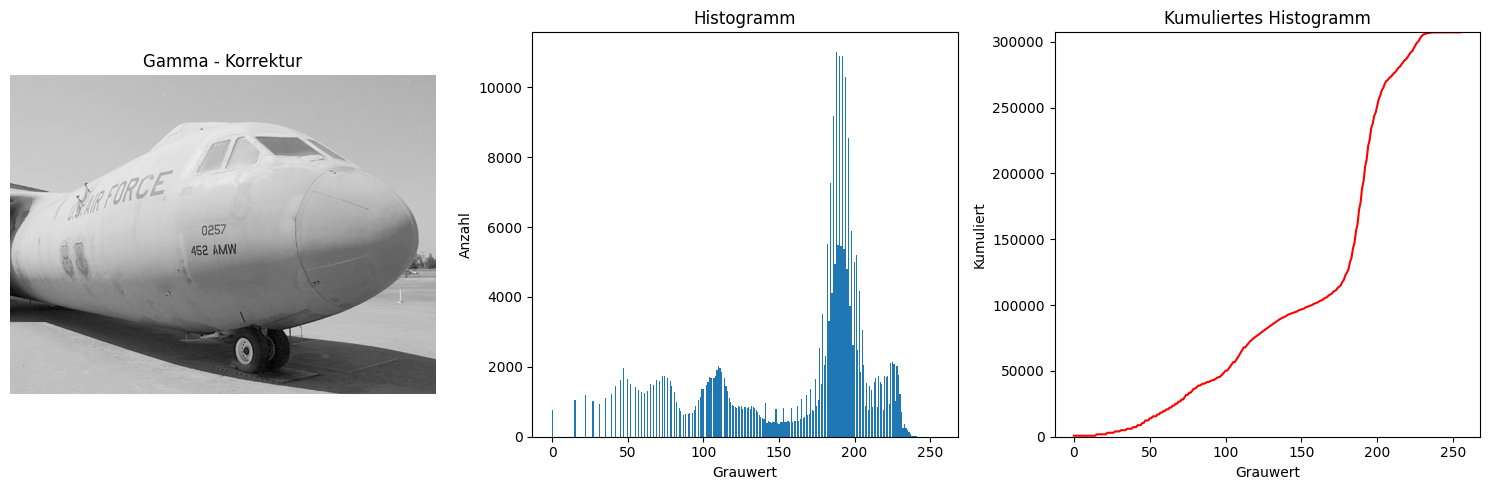

In [11]:
def adjustGamma(image, gamma):
    """Apply gamma correction to a grayscale image.

    Parameters:
    - image (numpy.ndarray): Input uint8 grayscale image.
    - gamma (float): Gamma value (>0). Values <1 brighten, >1 darken.
    Returns:
    - numpy.ndarray: Gamma-corrected image (uint8).
    """
    ##########
    ### ENTER YOUR CODE HERE
    ##########
    image_normalized = image.astype(np.float32) / 255.0
    # apply gamma
    image_corrected = image_normalized**gamma

    # clipping
    image_corrected = image_corrected * 255.0
    image_corrected = np.clip(image_corrected, 0, 255).astype(np.uint8)
    return image_corrected

# Aufruf der Funktion und Test
gamma = 0.5

image_gamma = adjustGamma(image, gamma)
displayImageAndAllHist(image_gamma, title = 'Gamma - Korrektur')